In [4]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [5]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [6]:

MAX_TOKENS = 150

In [7]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

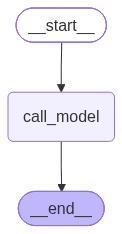

In [9]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")


checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

graph

In [11]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Sangram."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 40
Hi, my name is Nitish.
Hello Nitish! Nice to meet you. How can I assist you today?
Hi, my name is Sangram.


'Hello Sangram! Nice to meet you. How can I help you today?'

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 70
Hi, my name is Nitish.
Hello Nitish! Nice to meet you. How can I assist you today?
Hi, my name is Sangram.
Hello Sangram! Nice to meet you. How can I help you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM applications. Below is a quick overview to get you started, followed by some practical tips and resources you can dive into.\n\n---\n\n## 1️⃣ What Is LangGraph?\n\n- **Composable graph of “nodes”** – each node is a piece of logic (e.g., a prompt, a tool call, a custom Python function).  \n- **State‑driven execution** – a shared `State` object is passed along the edges, letting each node read/write data, decide the next step, and even loop back.\n- **Built on top of LangChain** – you can reuse all LangChain components (prompts, LLM wrappers, tools, memory, etc.) while gaining a clear, visualizable control flow.\n\nThink of it as a **flowchart for LLM reasoning**, where the flow can be dynamic (branching, looping) based on the LLM’s output or external signals.\n\n---\n\n## 2️⃣ Core Concepts\n\n| Concept | What It Does | Typical Use |\n|---------|--------------|-------------|\n| **Node** | A callabl

In [13]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑term memory (STM)** is the brain’s “scratch‑pad” for holding a small amount of information for a brief period—typically seconds to a few minutes—while we use it for ongoing tasks. It’s a core component of the broader **working memory** system, which not only stores but also manipulates information.\n\nBelow is a concise overview of the key features, underlying mechanisms, and practical implications of short‑term memory.\n\n---\n\n## 1. Core Characteristics\n\n| Feature | Typical Value | What It Means |\n|---------|---------------|---------------|\n| **Capacity** | 5‑9 items (often quoted as “7\u202f±\u202f2”) | You can keep about 5–9 discrete chunks (letters, digits, words, objects) in mind at once. |\n| **Duration** | 15‑30\u202fseconds (without rehearsal) | Information fades quickly unless you actively rehearse it. |\n| **Encoding** | Primarily **acoustic** (sound) and **visual** (spatial) | You tend to remember spoken numbers better than written ones, and you can hold a vis

In [14]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


'I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!'

In [15]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Nitish.
------------------------------------------------------------------------------------------------------------------------
Hello Nitish! Nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
Hi, my name is Sangram.
------------------------------------------------------------------------------------------------------------------------
Hello Sangram! Nice to meet you. How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM applications. Below is a quick overview to get you started, followed by some practical tips and resources you can 